# Notebook 03 — Label Creation
### WID2003 Cognitive Science | FSKTM, Universiti Malaya

---

## Overview

Machine learning classifiers require a **target label** — a class we want to predict. This notebook derives a binary performance label for each participant based on their accuracy across all 13 visual search tasks. This label becomes the target variable (`y`) for all models.

**Inputs**
| File | Description |
|---|---|
| `data/raw/student_responses.csv` | Response correctness per participant per task (auto-generated by `scripts/extract_click_responses.py`, or manually recorded) |
| `data/external/answer_key.json` | Confirmed correct AOI and task type for each stimulus |
| `data/processed/features_per_task.parquet` | Used to cross-check participant IDs |

**Output**
| File | Description |
|---|---|
| `data/processed/labels.csv` | One row per participant: accuracy score, performance label, speed label |

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the **median split** method for creating binary labels and identify its strengths and weaknesses
2. Compute an **accuracy rate** from per-task binary response data
3. Recognise the **class imbalance** problem and explain why imbalanced classes can mislead classifier evaluation
4. Discuss the ethical implications of labelling students as "high" or "low" performing based on a single session

---

## Background

### Measuring Performance

Participants completed 13 visual search tasks. Each task's correctness is derived from whether the participant's mouse click landed on the correct AOI (see `data_collection_manual.md` Part C):
- `1` = clicked the correct target region
- `0` = clicked elsewhere, or no click landed on any labelled AOI
- blank = no click recorded for that task

Each participant's **accuracy rate** = number of correct tasks ÷ 13.

### The Median Split

The **median split** divides participants at the midpoint of the accuracy distribution:

```
accuracy_rate >= median  →  High-performing  (Label = 1)
accuracy_rate <  median  →  Low-performing   (Label = 0)
```

This guarantees roughly balanced classes regardless of the score distribution. However, participants near the median are the hardest to classify correctly — a student who scores exactly at the median could plausibly belong to either group.

### Secondary Label: Speed

A `speed_label` (Fast / Slow) is derived from the mean `Time_to_first_fixation` on the correct AOI across all tasks — a gaze-derived measure of how quickly participants located the correct region.

### Student Responses File Format

`data/raw/student_responses.csv` must follow this schema:

| Column | Values |
|---|---|
| `participant_id` | Must match Tobii participant name exactly (lowercase) |
| `{task}_response` | `1`, `0`, or blank — one column per task (see `src.config.TASKS` for the full list of 13) |

See `data_collection_manual.md` Part C for details on how this file is produced.

---

## Discussion Questions

1. A participant scores 6/13. The group median is also 6/13. They are labelled "High-performing." Is this fair? How might you handle ties differently?
2. Not all 13 tasks are equally difficult. How could task difficulty bias the performance labels? What would you do to account for this?
3. If 70% of participants are High-performing, a model that always predicts "High" achieves 70% accuracy without learning anything. Why is this a problem, and what metric would you use instead?
4. The `speed_label` is derived from eye-tracking data rather than a stopwatch. What are the advantages and potential problems with this approach?
5. Discuss the ethical implications of labelling students as "low-performing" based on a 13-task session. How should such labels be communicated and used responsibly?

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/WID2003

!python -m pip install -q -r requirements.txt

# Important: notebook imports assume the working directory is notebooks/
%cd /content/drive/MyDrive/WID2003/notebooks

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_RAW, FEATURES_PER_TASK, LABELS_CSV, ANSWER_KEY_JSON,
    TASKS, PERFORMANCE_LABEL_COL, SPEED_LABEL_COL,
    LABEL_HIGH, LABEL_LOW, LABEL_FAST, LABEL_SLOW,
    MetricsCols
)

# Use mock responses if available, otherwise fall back to real data
# _mock = DATA_RAW / 'mock_student_responses.csv'
_real = DATA_RAW / 'student_responses.csv'
# RESPONSES_CSV = _mock if _mock.exists() else _real
RESPONSES_CSV = _real
print(f"Using: {RESPONSES_CSV.name}")

Using: student_responses.csv


## 1. Load student responses

In [2]:
if not RESPONSES_CSV.exists():
    raise FileNotFoundError(
        f"\n{RESPONSES_CSV} not found.\n"
        "Create it by running scripts/extract_click_responses.py, or by following "
        "data_collection_manual.md Part C.\n"
        f"Expected columns: participant_id, {', '.join(f'{t}_response' for t in TASKS)}\n"
        "Valid values: 1 (correct), 0 (incorrect), or blank"
    )

responses = pd.read_csv(RESPONSES_CSV)
responses['participant_id'] = responses['participant_id'].astype(str).str.strip().str.lower()
print(f"Loaded {len(responses)} participant responses")
responses.head()

Loaded 130 participant responses


,participant_id,Crown_response,findDice_response,Hat_response,Iguana_response,Rabbit_response,Shoe_response,T1_Prisoner-15sec_response,T2_Ring-15sec_response,T3_Umbrella-15 sec_response,T4_Pen-15sec_response,T5_Fish-15sec_response,T6_Heart-15sec_response,Toothbrush_response
0,vt1,0.0,1.0,1.0,NaN,1.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,0.0
1,vt10,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,0.0,NaN,0.0
2,vt100,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,1.0,0.0,NaN,1.0
3,vt101,0.0,1.0,1.0,0.0,1.0,1.0,NaN,NaN,0.0,1.0,0.0,NaN,0.0
4,vt102,0.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,0.0


## 2. Load answer key

In [3]:
# Answer key is loaded for reference — responses in student_responses.csv
# are already binary: 1 = correct, 0 = incorrect (recorded by operator).
with open(ANSWER_KEY_JSON) as f:
    answer_key = json.load(f)
answer_key = {k: v for k, v in answer_key.items() if not k.startswith('_')}

print("Answer key (for reference):")
for task, entry in answer_key.items():
    print(f"  {task}: correct_aoi={entry['correct_aoi']}, type={entry['task_type']}")

Answer key (for reference):
  Crown: correct_aoi=C1, type=find_object
  findDice: correct_aoi=D1, type=find_object
  Hat: correct_aoi=H1, type=find_object
  Iguana: correct_aoi=I0, type=find_object
  Rabbit: correct_aoi=R0, type=find_object
  Shoe: correct_aoi=S0, type=find_object
  T1_Prisoner-15sec: correct_aoi=P0, type=find_object
  T2_Ring-15sec: correct_aoi=G0, type=find_object
  T3_Umbrella-15 sec: correct_aoi=U0, type=find_object
  T4_Pen-15sec: correct_aoi=N0, type=find_object
  T5_Fish-15sec: correct_aoi=N1, type=find_object
  T6_Heart-15sec: correct_aoi=E0, type=find_object
  Toothbrush: correct_aoi=T0, type=find_object


## 3. Compute per-task accuracy

In [4]:
for task in TASKS:
    response_col = f'{task}_response'
    correct_col  = f'{task}_correct'

    if response_col not in responses.columns:
        print(f"WARNING: column '{response_col}' not found — setting to NaN")
        responses[correct_col] = np.nan
        continue

    # Responses are already binary: 1 = correct, 0 = incorrect.
    # Coerce to float so NaN is preserved for missing/NA entries.
    responses[correct_col] = pd.to_numeric(responses[response_col], errors='coerce')

correct_cols = [f'{t}_correct' for t in TASKS]
responses['total_score']   = responses[correct_cols].sum(axis=1)
responses['accuracy_rate'] = responses['total_score'] / len(TASKS)

print("Score distribution:")
responses[['total_score', 'accuracy_rate']].describe().round(3)

Score distribution:


,total_score,accuracy_rate
count,130.000,130.000
mean,6.000,0.462
std,2.153,0.166
min,0.000,0.000
25%,5.000,0.385
50%,6.000,0.462
75%,8.000,0.615
max,11.000,0.846


## 4. Create performance label (High / Low via median split)

In [5]:
median_accuracy = responses['accuracy_rate'].median()
print(f"Median accuracy rate: {median_accuracy:.3f} ({median_accuracy * len(TASKS):.1f}/{len(TASKS)} correct)")

responses[PERFORMANCE_LABEL_COL] = np.where(
    responses['accuracy_rate'] >= median_accuracy,
    LABEL_HIGH,  # 1 = High-performing
    LABEL_LOW    # 0 = Low-performing
)

label_counts = responses[PERFORMANCE_LABEL_COL].value_counts()
print(f"\nLabel distribution:")
print(f"  High (1): {label_counts.get(LABEL_HIGH, 0)}")
print(f"  Low  (0): {label_counts.get(LABEL_LOW,  0)}")

imbalance_ratio = label_counts.min() / label_counts.max()
if imbalance_ratio < 0.43:  # worse than 30/70
    print(f"\nWARNING: Class imbalance ratio = {imbalance_ratio:.2f}. Consider using balanced metrics.")

Median accuracy rate: 0.462 (6.0/13 correct)

Label distribution:
  High (1): 77
  Low  (0): 53


## 5. Create speed label (Fast / Slow) from response time

In [6]:
features = pd.read_parquet(FEATURES_PER_TASK)

# Aggregate mean response time (Time_to_first_mouse_click) across all tasks per participant
rt_col = f'correct_{MetricsCols.TIME_FIRST_MOUSE_CLICK}'

if rt_col in features.columns:
    mean_rt = (
        features.groupby('participant_id')[rt_col]
        .mean()
        .reset_index()
        .rename(columns={rt_col: 'mean_response_time_ms'})
    )
    responses = responses.merge(mean_rt, on='participant_id', how='left')

    median_rt = responses['mean_response_time_ms'].median()
    print(f"Median response time: {median_rt:.0f} ms")

    responses[SPEED_LABEL_COL] = np.where(
        responses['mean_response_time_ms'] <= median_rt,
        LABEL_FAST,  # 1 = Fast
        LABEL_SLOW   # 0 = Slow
    )
else:
    print(f"Column '{rt_col}' not found in features — speed_label set to NaN")
    responses[SPEED_LABEL_COL] = np.nan

print("\nSpeed label distribution:")
print(responses[SPEED_LABEL_COL].value_counts())

Median response time: 8168 ms

Speed label distribution:
speed_label
0    74
1    56
Name: count, dtype: int64


## 6. Participant ID cross-check

In [7]:
features_participants = set(features['participant_id'].unique())
label_participants    = set(responses['participant_id'].unique())

only_in_labels   = label_participants - features_participants
only_in_features = features_participants - label_participants

print(f"Participants in responses only (no eye-tracking): {only_in_labels}")
print(f"Participants in eye-tracking only (no responses): {only_in_features}")

if only_in_labels:
    print("\nWARNING: Some response records have no matching eye-tracking data. Check participant IDs.")

Participants in responses only (no eye-tracking): set()
Participants in eye-tracking only (no responses): set()


## 7. Visualize score and label distributions

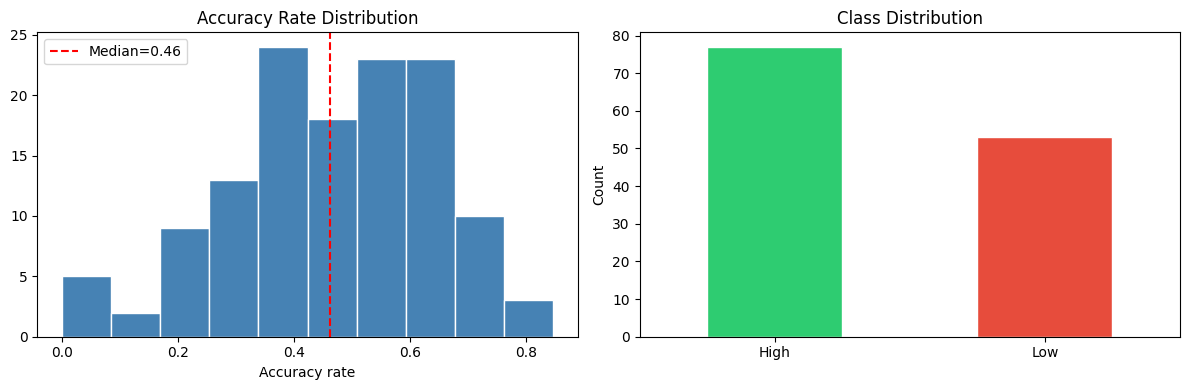

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy histogram
axes[0].hist(responses['accuracy_rate'], bins=10, color='steelblue', edgecolor='white')
axes[0].axvline(median_accuracy, color='red', linestyle='--', label=f'Median={median_accuracy:.2f}')
axes[0].set_title('Accuracy Rate Distribution')
axes[0].set_xlabel('Accuracy rate')
axes[0].legend()

# Label bar chart
label_map = {LABEL_HIGH: 'High', LABEL_LOW: 'Low'}
label_display = responses[PERFORMANCE_LABEL_COL].map(label_map).value_counts()
label_display.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Class Distribution')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/03_label_distribution.png', dpi=150)
plt.show()

## 8. Save labels

In [9]:
output_cols = (['participant_id', 'total_score', 'accuracy_rate',
                PERFORMANCE_LABEL_COL, SPEED_LABEL_COL] +
               correct_cols)

# Add mean_response_time if it exists
if 'mean_response_time_ms' in responses.columns:
    output_cols.append('mean_response_time_ms')

labels_out = responses[[c for c in output_cols if c in responses.columns]]
labels_out.to_csv(LABELS_CSV, index=False)

print(f"Saved: {LABELS_CSV}")
print(f"Shape: {labels_out.shape}")
labels_out.head()

Saved: /home/wlsoo/WID2003/data/processed/labels.csv
Shape: (130, 19)


,participant_id,total_score,accuracy_rate,performance_label,speed_label,Crown_correct,findDice_correct,Hat_correct,Iguana_correct,Rabbit_correct,Shoe_correct,T1_Prisoner-15sec_correct,T2_Ring-15sec_correct,T3_Umbrella-15 sec_correct,T4_Pen-15sec_correct,T5_Fish-15sec_correct,T6_Heart-15sec_correct,Toothbrush_correct,mean_response_time_ms
0,vt1,5.0,0.384615,0,0,0.0,1.0,1.0,NaN,1.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,0.0,14296.571429
1,vt10,9.0,0.692308,1,1,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,0.0,NaN,0.0,5909.100000
2,vt100,9.0,0.692308,1,0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,1.0,0.0,NaN,1.0,NaN
3,vt101,5.0,0.384615,0,1,0.0,1.0,1.0,0.0,1.0,1.0,NaN,NaN,0.0,1.0,0.0,NaN,0.0,8028.600000
4,vt102,6.0,0.461538,1,1,0.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,0.0,6834.714286
